In [1]:
#통계 검증 예제1
# (1) 타이타닉호 데이터
#      - 타이타닉호 티켓 가격에 따른 생존률이 궁금하다.
#      -> 생존자 그룹과 비생존자 그룹 간, 타이타닉호 탑승권의 가격은 달랐을 것이다.
#
#      Ho : 생존자 그룹의 타이타닉호 평균 탑승권 가격 == 비생존자 그룹의 타이타닉호 평균 탑승권 가격
#      Ha : 생존자 그룹의 타이타닉호 평균 탑승권 가격 > 비생존자 그룹의 타이타닉호 평균 탑승권 가격

In [3]:
getwd()

[1] "/content"

In [5]:
list.files()

[1] "sample_data"        "Titanic_exdata.csv"

In [6]:
# CSV 파일 불러오기
titanic_df <- read.csv('/content/Titanic_exdata.csv')

# 데이터프레임의 첫 5행 표시
cat("불러온 데이터의 첫 5행:\n")
print(head(titanic_df))

불러온 데이터의 첫 5행:
  PassengerId Survived Pclass
1           1        0      3
2           2        1      1
3           3        1      3
4           4        1      1
5           5        0      3
6           6        0      3
                                                 Name    Sex Age SibSp Parch
1                             Braund, Mr. Owen Harris   male  22     1     0
2 Cumings, Mrs. John Bradley (Florence Briggs Thayer) female  38     1     0
3                              Heikkinen, Miss. Laina female  26     0     0
4        Futrelle, Mrs. Jacques Heath (Lily May Peel) female  35     1     0
5                            Allen, Mr. William Henry   male  35     0     0
6                                    Moran, Mr. James   male  NA     0     0
            Ticket    Fare Cabin Embarked
1        A/5 21171  7.2500              S
2         PC 17599 71.2833   C85        C
3 STON/O2. 3101282  7.9250              S
4           113803 53.1000  C123        S
5           373450  8.0500

이제 `Fare` (요금) 데이터를 생존 여부(Survived)에 따라 두 그룹으로 분리하고, 단측 t-검정을 수행하겠습니다.

In [7]:
# 생존자 그룹과 비생존자 그룹으로 분리
# R에서는 subset을 사용하여 조건을 만족하는 데이터를 추출할 수 있습니다.
survivors_fare <- subset(titanic_df, Survived == 1)$Fare
non_survivors_fare <- subset(titanic_df, Survived == 0)$Fare

# 결측값 제거 (t.test는 NA를 자동으로 처리하지 않으므로 명시적으로 제거)
survivors_fare <- na.omit(survivors_fare)
non_survivors_fare <- na.omit(non_survivors_fare)

# 독립 표본 t-검정 수행 (단측 검정)
# Ha : 생존자 그룹의 타이타닉호 평균 탑승권 가격 > 비생존자 그룹의 타이타닉호 평균 탑승권 가격
# alternative = "greater"를 사용하여 단측 검정 수행
# var.equal = FALSE는 Welch's t-test를 의미합니다.
t_test_result <- t.test(survivors_fare, non_survivors_fare, alternative = "greater", var.equal = FALSE)

# 결과 추출
t_statistic <- t_test_result$statistic
one_tailed_p_value <- t_test_result$p.value

mean_survivors <- mean(survivors_fare)
mean_non_survivors <- mean(non_survivors_fare)

cat(sprintf("생존자 그룹 평균 Fare: %.2f\n", mean_survivors))
cat(sprintf("비생존자 그룹 평균 Fare: %.2f\n", mean_non_survivors))
cat(sprintf("T-statistic: %.3f\n", t_statistic))
cat(sprintf("단측 p-value: %.3f\n", one_tailed_p_value))

# 결과 해석
alpha <- 0.05 # 유의수준

if (one_tailed_p_value < alpha) {
    cat(sprintf("\n(단측 p-value %.3f < 유의수준 %.2f)\n", one_tailed_p_value, alpha))
    cat("귀무가설(Ho)을 기각합니다. 생존자 그룹의 평균 탑승권 가격이 비생존자 그룹보다 통계적으로 유의하게 높다고 할 수 있습니다.\n")
} else {
    cat(sprintf("\n(단측 p-value %.3f >= 유의수준 %.2f)\n", one_tailed_p_value, alpha))
    cat("귀무가설(Ho)을 기각할 충분한 증거가 없습니다. 생존자 그룹의 평균 탑승권 가격이 비생존자 그룹보다 통계적으로 유의하게 높다고 할 수 없습니다.\n")
}

생존자 그룹 평균 Fare: 48.40
비생존자 그룹 평균 Fare: 22.12
T-statistic: 6.839
단측 p-value: 0.000

(단측 p-value 0.000 < 유의수준 0.05)
귀무가설(Ho)을 기각합니다. 생존자 그룹의 평균 탑승권 가격이 비생존자 그룹보다 통계적으로 유의하게 높다고 할 수 있습니다.


#### **결과 해석 가이드:**

*   **T-statistic**: 이 값이 양수이면 생존자 그룹의 평균 요금이 비생존자 그룹보다 높다는 것을, 음수이면 그 반대임을 의미합니다.
*   **단측 p-value**: 이 값이 미리 설정한 유의수준(일반적으로 0.05)보다 작으면, 귀무가설(Ho: 두 그룹의 평균 요금이 같다)을 기각하고 대립가설(Ha: 생존자 그룹의 평균 요금이 비생존자 그룹보다 높다)을 채택합니다.

이 분석은 생존 여부가 `Fare`에 미치는 영향을 이해하는 데 도움을 줍니다.

#메뉴얼 t-test
* t-test 하려면!

1) z-test 안하는 이유
   : 모분산을 모른다 (전수조사면 가능)
   -> t-test (정규성)나 Wilcoxon rank-sum test(정규성X) 해야함

2) 정규성 가정 확인
   -> shapiro-wilk normality test
   : 유의하면 정규성 아님!

*** 중심극한정리 (CLT 이론)
   : 샘플이 30개가 넘어 가면, 모집단의 분포와 관계없이 표본평균(X)의 분포는 정규분포에 근사함. 그때의 표본평균은 정규성을 띈다.
   : 두 그룹이면 각 그 그룹이 30이 넘어가는 것을 권고 (근거는 없음, 통계학자들의 경험임)
   -> 정규성도 안찍고, 샘플이 30개도 안된다? -> 5) 이동

3) 등분산성 확인
   -> F-test (정규성 띌 때만 가능!)
   : 유의하면 이분산
   * var.test(survived_group$Fare, not_survived_group$Fare)

   -> Levene's Test (정규성 안 될때, 대부분 가능!, 표준방법)
   : 유의하면 이분산
   *levene test는 단측 검정만 함.

4-1) t-test 수행 (정규성 & 이분산)
     -> Welch's t-test
     -> t.test(x, y)

4-2) t-test 수행 (정규성 & 등분산)
     -> Student's t-test
     -> t.test(x, y, var.equal=TRUE)

5-1) Wilcoxon rank-sum test (정규성 가정 필요없는 비모수적 방법, 근데, 두 집단의 분포 모양은 비슷해야 좋음. 다른 말로 Mann-Whitney U test)
     -> wilcox.test(x, y, alternative="two.sided")

In [12]:
shapiro.test(survivors_fare)
shapiro.test(non_survivors_fare)


	Shapiro-Wilk normality test

data:  survivors_fare
W = 0.59673, p-value < 2.2e-16



	Shapiro-Wilk normality test

data:  non_survivors_fare
W = 0.51304, p-value < 2.2e-16


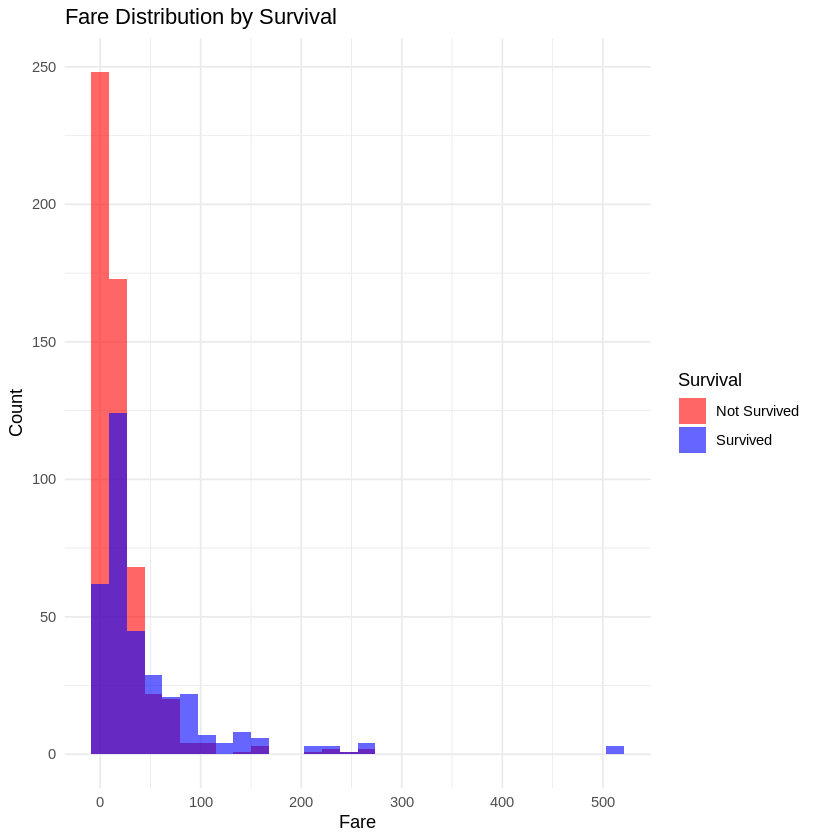

In [16]:
library(ggplot2)
# 생존 여부별 분포 시각화
ggplot(titanic_df, aes(x = Fare, fill = as.factor(Survived))) +
  geom_histogram(bins = 30, alpha = 0.6, position = "identity") +
  scale_fill_manual(values = c("red", "blue"), labels = c("Not Survived", "Survived")) +
  labs(title = "Fare Distribution by Survival", x = "Fare", y = "Count", fill = "Survival") +
  theme_minimal()

In [17]:
titanic_df

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S


In [19]:
install.packages('lawstat')
library(lawstat)
titanic_df$Survived <- as.factor(titanic_df$Survived)
levene.test(titanic_df$Fare, titanic_df$Survived, location = "mean")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	Classical Levene's test based on the absolute deviations from the mean
	( none not applied because the location is not set to median )

data:  titanic_df$Fare
Test Statistic = 82.918, p-value < 2.2e-16


In [20]:
var.test(survivors_fare, non_survivors_fare)


	F test to compare two variances

data:  survivors_fare and non_survivors_fare
F = 4.5017, num df = 341, denom df = 548, p-value < 2.2e-16
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 3.725366 5.463382
sample estimates:
ratio of variances 
          4.501697 


In [21]:
#t-test 및 비교
t.test(survivors_fare, non_survivors_fare, alternative = "greater")


	Welch Two Sample t-test

data:  survivors_fare and non_survivors_fare
t = 6.8391, df = 436.7, p-value = 1.35e-11
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 19.94415      Inf
sample estimates:
mean of x mean of y 
 48.39541  22.11789 


In [22]:
t.test(survivors_fare, non_survivors_fare, alternative = "greater", var.equal = TRUE)


	Two Sample t-test

data:  survivors_fare and non_survivors_fare
t = 7.9392, df = 889, p-value = 3.06e-15
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 20.82763      Inf
sample estimates:
mean of x mean of y 
 48.39541  22.11789 


In [23]:
wilcox.test(survivors_fare, non_survivors_fare, alternative = "greater")


	Wilcoxon rank sum test with continuity correction

data:  survivors_fare and non_survivors_fare
W = 129952, p-value < 2.2e-16
alternative hypothesis: true location shift is greater than 0


In [24]:
sleep_data <- read.csv('/content/Sleep_drug.txt', sep="\t", header = T)
sleep_data

ID,Before,After
<int>,<int>,<dbl>
1,10,7.0
2,9,8.0
3,8,7.5
4,9,6.0
5,11,9.0
6,13,11.0
7,10,12.0
8,9,13.0
9,11,11.0


In [25]:
# diff 계산 (After - Before)
sleep_data$diff <- sleep_data$After - sleep_data$Before

In [26]:
# 정규성 검정 (Shapiro-Wilk)
#    귀무가설: diff는 정규분포를 따른다.
#    p-value > 0.05 : 정규성 만족
#    p-value <= 0.05 : 정규성 위반. t-test 조심하고 비모수검정 필요

shapiro.test(sleep_data$diff)


	Shapiro-Wilk normality test

data:  sleep_data$diff
W = 0.91414, p-value = 0.07647


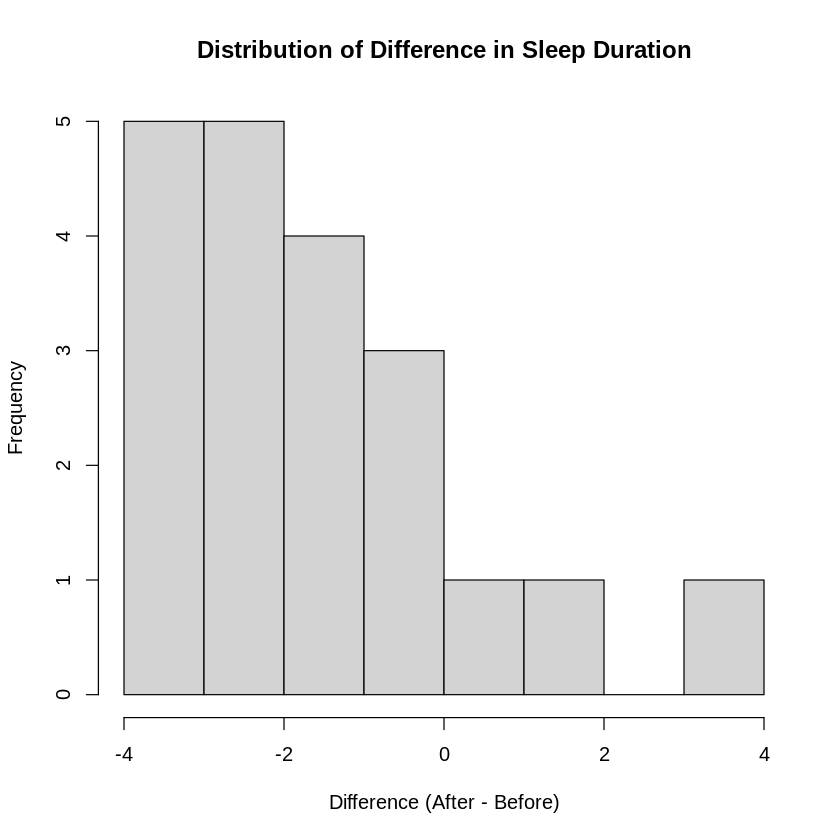

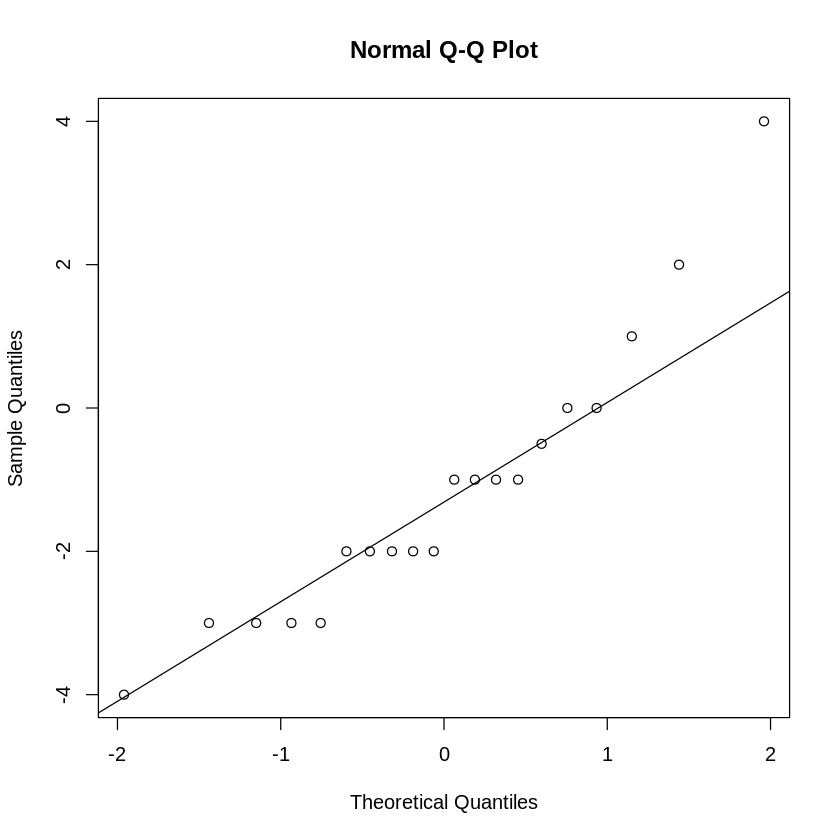

In [28]:
# diff의 분포 확인(히스토그램)
hist(sleep_data$diff, main = "Distribution of Difference in Sleep Duration", xlab = "Difference (After - Before)", ylab = "Frequency")

qqnorm(sleep_data$diff)
qqline(sleep_data$diff)

In [29]:
# 3. 대응표본 t-test (단측검정)(Paired t-test)
#           귀무가설: After - Before = 0 (차이 없음)
#           대립가설: After - Before < 0 (수면시간 줄었다)

t.test(sleep_data$After, sleep_data$Before, paired = TRUE, alternative = "less")


	Paired t-test

data:  sleep_data$After and sleep_data$Before
t = -2.7448, df = 19, p-value = 0.00644
alternative hypothesis: true mean difference is less than 0
95 percent confidence interval:
       -Inf -0.4347846
sample estimates:
mean difference 
         -1.175 


In [30]:
wilcox.test(sleep_data$After, sleep_data$Before, paired = TRUE, alternative = "less")

Warning message in wilcox.test.default(sleep_data$After, sleep_data$Before, paired = TRUE, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sleep_data$After, sleep_data$Before, paired = TRUE, :
“cannot compute exact p-value with zeroes”



	Wilcoxon signed rank test with continuity correction

data:  sleep_data$After and sleep_data$Before
V = 31, p-value = 0.008886
alternative hypothesis: true location shift is less than 0
